# DBNets2.0. Tutorial: application to an actual observation
In this jupyter notebook the tool is applied to MWC480 (data from the ALMA archive)

1. Install DBNets following the instructions provided on the github repo.

2. Import the DBNets2 library and initialize the models. Provide the paths of the trained CNN and Normalizing Flows.

In [1]:
from DBNets import DBNets2
import matplotlib.pyplot as plt

dbnets = DBNets2()

2025-11-14 12:32:24.371738: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763119944.386228   29511 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763119944.390100   29511 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763119944.402266   29511 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763119944.402285   29511 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763119944.402287   29511 computation_placer.cc:177] computation placer alr

3. Collect the data needed on the protoplanetary disc under exam
    - fits file with the continuum observation in ALMA band 6 or 7
    - centre of the disc in pixel coordinates
    - inclination
    - position angle
    - planet position (as an angle or as distance + physical separation)

![definition of inclination and position angle](inclandpa.png)

In [2]:
file_name = 'mwc480.fits'
centre = (1024, 1026)
inclination = 36
pa = 58
distance = 161
rp = 73
res_ba_arcsec = 0.15

#define the image resolution in the same code units used in the code
res_sigma = res_ba_arcsec/2.35*distance/rp

(-0.5, 2047.5, 2047.5, -0.5)

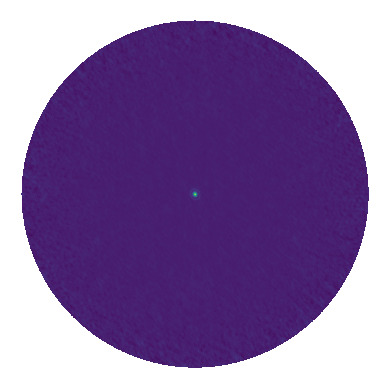

In [3]:
#you can check the image
from astropy.io import fits

hdu = fits.open(file_name)[0]
plt.imshow(hdu.data[0,0])
plt.axis('off')

4. use DBNets.preproc module to open and preprocess the fits file. This function opens the fits file, rescales and deprojects the disc to make the observation geometrically homogeneous with the synthetic observations used to train the ensemble. The following picture shows the data before and after.

![preprocessing](preprocess.png)

In [4]:
from DBNets import preproc as pp
deproj_image = pp.deproject_image(file_name, distance, inclination, pa, centre, rp)

this is the image obtained

(-0.5, 127.5, 127.5, -0.5)

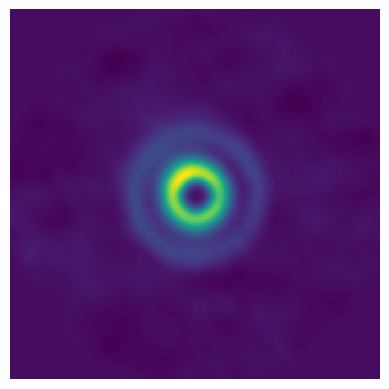

In [5]:
import matplotlib.pyplot as plt
plt.imshow(deproj_image)
plt.axis('off')

5. run the inference sampling N points from the inferred posterior

In [6]:
samples, cs = dbnets(deproj_image, [0.4], nsamples=500)

2025-11-14 12:32:40.065555: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 629145600 exceeds 10% of free system memory.
2025-11-14 12:32:40.161295: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 629145600 exceeds 10% of free system memory.
2025-11-14 12:32:40.305857: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 629145600 exceeds 10% of free system memory.
2025-11-14 12:32:40.412504: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 629145600 exceeds 10% of free system memory.
2025-11-14 12:32:40.718593: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 629145600 exceeds 10% of free system memory.


Drawing 109 posterior samples:   0%|          | 0/109 [00:00<?, ?it/s]

Drawing 95 posterior samples:   0%|          | 0/95 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 98 posterior samples:   0%|          | 0/98 [00:00<?, ?it/s]

Drawing 98 posterior samples:   0%|          | 0/98 [00:00<?, ?it/s]

loading all data and parameters
Sample 10 estimates from the posteriror distribution
Interpolating 10 best estimates
Standardize data
FFT
done.
 Compute metric..
DONE!


The method returns `nsamples` samples from the inferred posterior.

These are returned in an array we the following shape: (ninputs, nsamples, 4).

__The last dimension corresponds to the 4 inferred properties in the following order: Alpha, AspectRatio, Stokes, Planet to Star mass ratio__.

In [8]:
import numpy as np
np.median(np.nan_to_num(samples), axis=1)

array([[0.00016947, 0.13676289, 0.01207861, 0.0006967 ]])

You can plot these results, for example, using the function `utils.plot_corner`.

In [9]:
from DBNets import utils

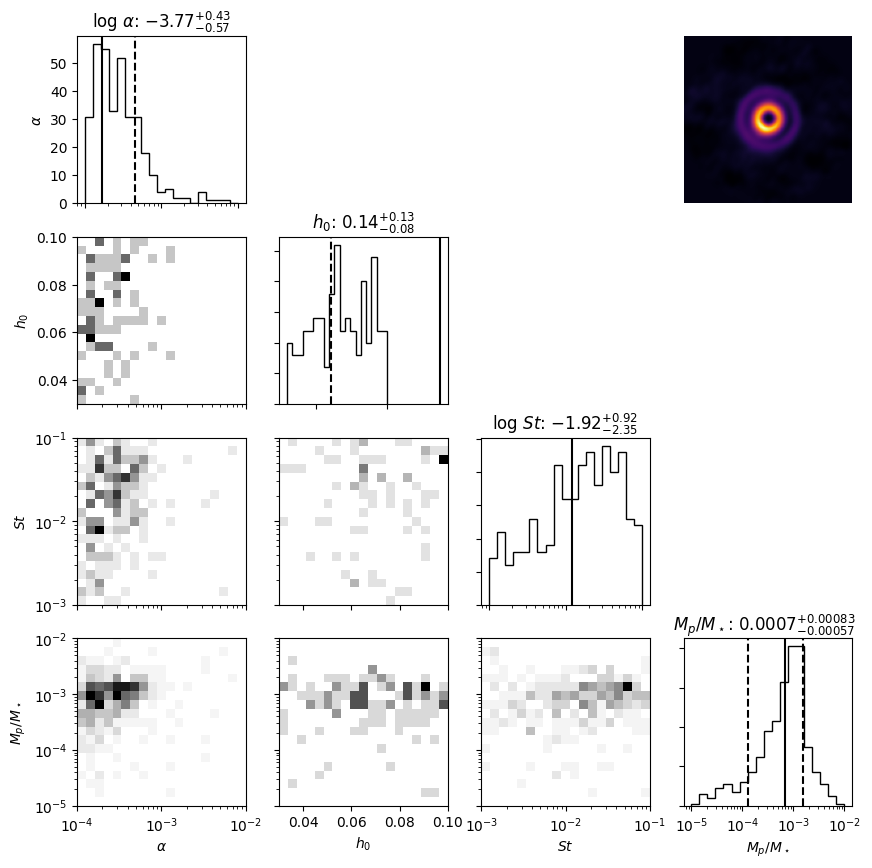

In [10]:
utils.plot_corner(samples[0],name='mwc480', savepath='corner.pdf', image = deproj_image)